# Analiza jakości powietrza — Kraków, os. Piastów (2016–2025)

To jest **notebook zaliczeniowy** dla kursu **Data Science (Python) + wstęp do Machine Learning** realizowanego w ramach projektu Małopolskiego.
Pracujesz na rzeczywistych danych środowiskowych: dzienne **AQI** dla `PM2.5`, `PM10`, `O3`, `NO2`, `SO2`, `CO`.

## Kontekst merytoryczny
- **AQI (Air Quality Index)** to indeks jakości powietrza skalowany tak, aby różne zanieczyszczenia można było porównywać w jednej skali ryzyka zdrowotnego.  
- W tym zbiorze wartości dla każdej substancji to **indywidualne współczynniki AQI** — zostały już przeliczone z surowych stężeń (mg/m³, ppm, ppb) według standardu **EPA**.
- **Złożony AQI** dla dnia definiuje się jako **maksimum** spośród dostępnych indywidualnych wskaźników:  
$$
AQI_{\text{total}} = \max(AQI_{PM2.5}, AQI_{PM10}, AQI_{O3}, AQI_{NO2}, AQI_{SO2}, AQI_{CO})
$$
  Taki wybór odzwierciedla najbardziej dokuczliwy czynnik zdrowotny danego dnia.

## Zakres danych i źródła
- Lokalizacja: **Kraków, os. Piastów, Małopolska, Poland**
- Zakres: **średni dzienny AQI** od **23 stycznia 2016** do **listopada 2025** (ok. 119 miesięcy)
- Plik: **`data.csv`** (w tym samym folderze co notebook)
- Źródła danych:
  - Regional Inspectorate for Environmental Protection in Krakow (WIOŚ Kraków) / Główny Inspektorat Ochrony Środowiska
  - Kanały danych:
    - Historyczne: aqicn.org/historical/#city:poland/malopolska/krakow--os.-piastow
    - Bieżące: aqicn.org/station/poland/malopolska/krakow--os.-piastow

## Wymagania zaliczeniowe

- **Zadania 1–7 oraz 10** są **obowiązkowe** — wszystkie muszą być ukończone, aby zaliczyć projekt.
- **Zadania 8–9** są **dodatkowe** — ich wykonanie jest opcjonalne.
- Po niektórych zadaniach znajduje się komórka weryfikacyjna (`# Weryfikacja`). Uruchom ją, aby sprawdzić, czy Twoje rozwiązanie spełnia podstawowe wymagania. Wszystkie asercje powinny przejść bez błędów.

In [2]:
# Import potrzebnych bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print("Środowisko gotowe — pandas:", pd.__version__)

Środowisko gotowe — pandas: 3.0.2


## Zadanie 1 — Wczytanie i pierwszy przegląd danych
**Co zrobisz:** załaduj plik `data.csv` do DataFrame o nazwie `df`, konwertując kolumnę `date` na typ daty (`parse_dates`). Wyświetl kilka pierwszych wierszy, sprawdź typy kolumn metodą `info()` oraz policz brakujące wartości w każdej kolumnie.

**Po co:** żeby upewnić się, że plik jest poprawny, a daty są interpretowane jako daty.

**Do przemyślenia:**
- Jaki typ danych ma kolumna `date` po wczytaniu? Czy pandas automatycznie rozpoznaje daty?
- Ile brakujących wartości ma każda kolumna? Która kolumna ma ich najwięcej?

**Oczekiwany rezultat:** DataFrame `df` z 7 kolumnami, ~3496 wierszy, kolumna `date` typu `datetime64`.

In [3]:
df=pd.read_csv('data.csv')
print(df.head())
df.dtypes
df['date'] = pd.to_datetime(df['date'])
print(df.dtypes)
df.info

         date  pm25    pm10  o3  no2  so2  co
0  2016-01-23   NaN 124.000 NaN  NaN  NaN NaN
1  2016-01-24   NaN  59.000 NaN  NaN  NaN NaN
2  2016-01-25   NaN  44.000 NaN  NaN  NaN NaN
3  2016-01-26   NaN  40.000 NaN  NaN  NaN NaN
4  2016-01-27   NaN  31.000 NaN  NaN  NaN NaN
date    datetime64[us]
pm25           float64
pm10           float64
o3             float64
no2            float64
so2            float64
co             float64
dtype: object


<bound method DataFrame.info of            date    pm25    pm10    o3    no2   so2  co
0    2016-01-23     NaN 124.000   NaN    NaN   NaN NaN
1    2016-01-24     NaN  59.000   NaN    NaN   NaN NaN
2    2016-01-25     NaN  44.000   NaN    NaN   NaN NaN
3    2016-01-26     NaN  40.000   NaN    NaN   NaN NaN
4    2016-01-27     NaN  31.000   NaN    NaN   NaN NaN
...         ...     ...     ...   ...    ...   ...  ..
3491 2025-11-04  61.000  39.000 4.000  9.000 1.000 NaN
3492 2025-11-05  87.000  41.000 7.000 11.000 1.000 NaN
3493 2025-11-06 100.000  37.000 9.000 10.000 1.000 NaN
3494 2025-11-07  88.000  29.000 2.000  6.000 1.000 NaN
3495 2025-11-08  83.000     NaN   NaN    NaN   NaN NaN

[3496 rows x 7 columns]>

In [4]:
# Weryfikacja — Zadanie 1
assert "df" in globals(), "Brak zmiennej 'df' — wczytaj dane do DataFrame o nazwie df"
assert isinstance(df, pd.DataFrame), "df powinien być obiektem pd.DataFrame"
assert df.shape[1] == 7, f"Oczekiwano 7 kolumn, jest {df.shape[1]}"
assert df.shape[0] > 3000, f"Za mało wierszy ({df.shape[0]}) — czy wczytano właściwy plik?"
assert pd.api.types.is_datetime64_any_dtype(df["date"]), "Kolumna 'date' powinna być typu datetime — użyj parse_dates"
print("Zadanie 1 — OK")

Zadanie 1 — OK


## Zadanie 2 — Braki danych i przygotowanie do analizy
**Co zrobisz:** zidentyfikuj i uzupełnij brakujące dane w kolumnach z AQI, wybierając podejście, które zachowuje ciągłość w czasie. Następnie, dla bezpieczeństwa, upewnij się, że nie ma wartości ujemnych metodą `clip`: https://pandas.pydata.org/docs/reference/api/pandas.Series.clip.html

**Po co:** braki mogą pochodzić z przerw pomiarowych; ich łagodne uzupełnienie umożliwia spójne wykresy i obliczenia. AQI z definicji jest nieujemny, więc `clip(lower=0)` działa tu profilaktycznie — w tym konkretnym pliku wartości ujemne nie występują, ale to dobry nawyk na przyszłe zbiory danych.

**Kolumny AQI do uzupełnienia:** `pm25`, `pm10`, `o3`, `no2`, `so2`, `co`

**Ważna uwaga o strukturze danych:**
Stacja pomiarowa **nie mierzyła wszystkich substancji od początku**. Kolumna `pm10` ma dane od 2016 roku, ale pozostałe kolumny (`pm25`, `no2`, `so2`, `co`, `o3`) zaczynają się dopiero od **~maja 2018**. Oznacza to, że na początku pliku jest kilkaset wierszy, w których te kolumny są całkowicie puste. To nie jest błąd w danych — to odzwierciedla rzeczywistą historię pomiarów.

**Do przemyślenia:**
- Dane są szeregiem czasowym — czy lepiej uzupełnić braki średnią, czy może wartością z poprzedniego/następnego dnia?
- Porównaj `df["kolumna"].ffill()` z `df["kolumna"].interpolate()`. Która metoda lepiej oddaje naturę pomiarów powietrza?
- Sama metoda `ffill()` lub `interpolate()` **nie wystarczy** dla braków na początku kolumny (nie ma wcześniejszej wartości do propagacji). Zastanów się, jak uzupełnić te początkowe braki — pomocna może być metoda `bfill()`, która propaguje wartości **wstecz**.
- Uzupełnianie braków rób **przed** wywołaniem `.clip(lower=0)` — `clip` nie zmienia wartości `NaN`.

**Oczekiwany rezultat:** DataFrame `df` bez wartości `NaN` w kolumnach AQI i bez wartości ujemnych.

In [ ]:
kol_aqi = ["pm25", "pm10", "o3", "no2", "so2", "co"]
for col in kol_aqi:
    df[col] = (
        df[col]
        .interpolate(method="linear")
        .ffill()
        .bfill()
        .clip(lower=0)
    )

print(df[kol_aqi].isna().sum())

print(df[kol_aqi].min())

pm25    0
pm10    0
o3      0
no2     0
so2     0
co      0
dtype: int64
pm25   8.000
pm10   4.000
o3     1.000
no2    1.000
so2    1.000
co     1.000
dtype: float64


In [8]:
# Weryfikacja — Zadanie 2
_aqi_cols = ["pm25", "pm10", "o3", "no2", "so2", "co"]
_missing = df[_aqi_cols].isnull().sum()
assert _missing.sum() == 0, f"Nadal są braki danych:\n{_missing[_missing > 0]}"
assert (df[_aqi_cols] >= 0).all().all(), "Znaleziono wartości ujemne — użyj .clip(lower=0)"
print("Zadanie 2 — OK")

Zadanie 2 — OK


## Zadanie 3 — Statystyki opisowe i przygotowanie pól czasowych
**Co zrobisz:**  
1. Wyświetl statystyki opisowe (`.describe()`) dla kolumn AQI.
2. Dodaj do `df` dwie nowe kolumny: `year` (rok) i `month` (miesiąc), wyciągnięte z kolumny `date`.

Przykład dla miesiąca w dokumentacji Pandas: https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.month.html   

**Po co:** aby rozumieć typowe poziomy, zmienność i przygotować się do analiz sezonowości.

**Do przemyślenia:**
- Która substancja ma największe odchylenie standardowe? Co to oznacza w praktyce?
- Czy średnia i mediana znacząco się różnią? Jeśli tak — co to mówi o rozkładzie danych?

**Oczekiwany rezultat:** kolumny `year` i `month` w DataFrame `df`.

In [ ]:
df[kol_aqi].describe()
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df[["date", "year", "month"]].head()


,date,year,month
0,2016-01-23,2016,1
1,2016-01-24,2016,1
2,2016-01-25,2016,1
3,2016-01-26,2016,1
4,2016-01-27,2016,1


In [15]:
# Weryfikacja — Zadanie 3
assert "year" in df.columns, "Brak kolumny 'year' w DataFrame"
assert "month" in df.columns, "Brak kolumny 'month' w DataFrame"
assert df["year"].between(2016, 2025).all(), "Kolumna 'year' zawiera wartości spoza zakresu 2016–2025"
assert df["month"].between(1, 12).all(), "Kolumna 'month' powinna zawierać wartości 1–12"
print("Zadanie 3 — OK")

Zadanie 3 — OK


## Zadanie 4 — Trend czasowy dla PM2.5
**Co zrobisz:** przedstaw na wykresie liniowym, jak zmieniały się wartości PM2.5 w czasie. Aby oś X była poprawnie traktowana jako czas, skorzystaj z `date` jako indeksu — np. rysując wprost `df.set_index("date")["pm25"].plot(...)`.

**Po co:** PM2.5 to drobne cząstki szczególnie ważne zdrowotnie; długi horyzont pokazuje trendy i sezonowość.

**Wymagania wykresu:**
- Tytuł wykresu
- Podpisane osie (X: data, Y: AQI PM2.5)
- Czytelny rozmiar (`figsize` co najmniej 12×4)

**Wskazówka techniczna:** jeżeli użyjesz `df.set_index("date", inplace=True)` lub przypiszesz wynik do `df`, kolumna `date` zniknie z DataFrame — co utrudni późniejsze zadania (np. Zadanie 7, które odwołuje się do kolumny `date`). Bezpieczniej jest ustawić indeks **tylko lokalnie na potrzeby wykresu**, nie modyfikując `df`.

**Do przemyślenia:**
- Dlaczego warto ustawić datę jako indeks przed rysowaniem wykresu czasowego?
- Czy widzisz powtarzający się wzorzec w ciągu roku? Co może go powodować?

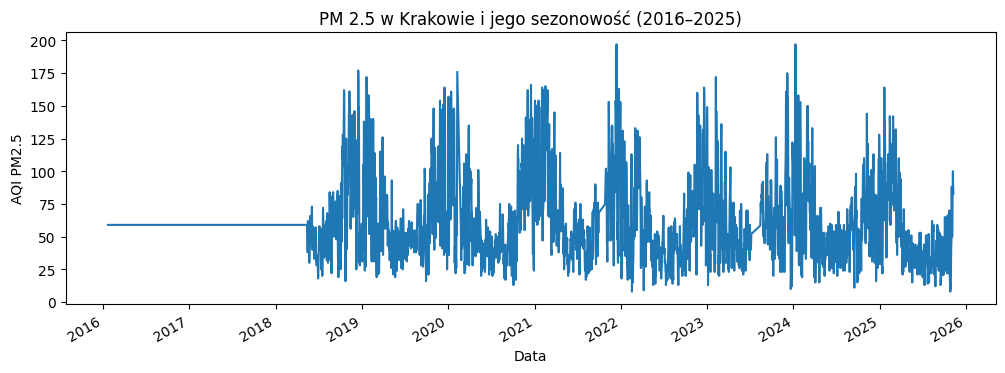

In [16]:
plt.figure(figsize=(12, 4))

df.set_index("date")["pm25"].plot()

plt.title("PM 2.5 w Krakowie i jego sezonowość (2016–2025)")
plt.xlabel("Data")
plt.ylabel("AQI PM2.5")

plt.show()

## Zadanie 5 — Współwystępowanie zanieczyszczeń
**Co zrobisz:** oblicz macierz korelacji (`.corr()`) między kolumnami AQI i zwizualizuj ją jako heatmapę — np. za pomocą `sns.heatmap()` z parametrem `annot=True`.

**Po co:** wysokie współwystępowanie może sugerować wspólne źródła emisji lub podobne warunki meteorologiczne.

**Do przemyślenia:**
- Czym jest współczynnik korelacji Pearsona i jak interpretować jego wartości (-1 do 1)?
- Które pary substancji są najsilniej skorelowane? Czy potrafisz wyjaśnić dlaczego?

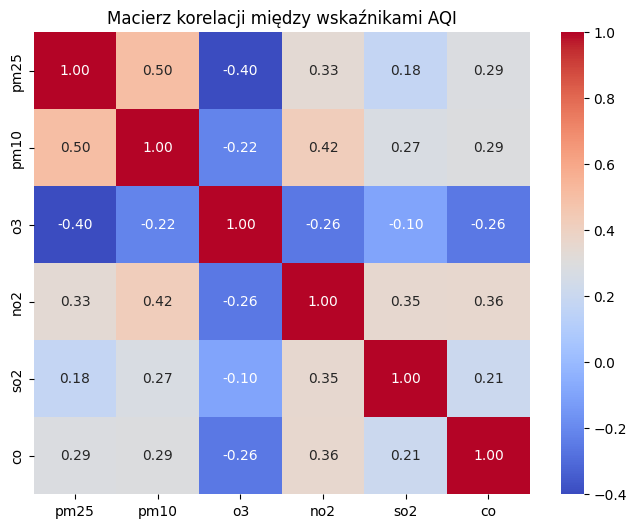

In [ ]:
corr_matrix = df[kol_aqi].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Macierz korelacji między wskaźnikami AQI")
plt.show()

## Zadanie 6 — Obliczanie złożonego AQI (wg EPA)
**Co zrobisz:**  
1. Dodaj do `df` kolumnę `aqi` zawierającą złożony AQI = maksimum z kolumn AQI w każdym wierszu.
2. Policz, ile dni miało AQI > 100 (pogorszona jakość powietrza).
3. Przedstaw przebieg złożonego AQI w czasie na wykresie liniowym.

**Po co:** złożony AQI streszcza ryzyko zdrowotne dnia — „najgorszy" składnik decyduje o wyniku.

**Do przemyślenia:**
- Jak policzyć maksimum w wierszu, a nie w kolumnie? Sprawdź parametr `axis` w metodzie `.max()`.
- Po Zadaniu 2 w kolumnach AQI nie powinno już być braków. Gdyby jednak zostały — jak `.max()` zachowuje się wobec `NaN` (parametr `skipna`)?

**Oczekiwany rezultat:** nowa kolumna `aqi` w DataFrame `df`.

Liczba dni z AQI > 100: 368


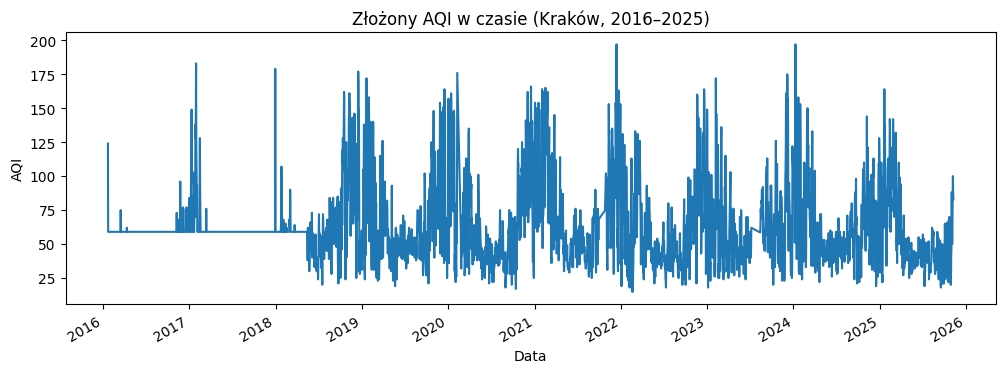

In [ ]:

df["aqi"] = df[kol_aqi].max(axis=1)


bad_air = (df["aqi"] > 100).sum()

print("Liczba dni z AQI > 100:", bad_air)

plt.figure(figsize=(12, 4))

df.set_index("date")["aqi"].plot()

plt.title("Złożony AQI w czasie (Kraków, 2016–2025)")
plt.xlabel("Data")
plt.ylabel("AQI")

plt.show()

In [25]:
# Weryfikacja — Zadanie 6
assert "aqi" in df.columns, "Brak kolumny 'aqi' — dodaj ją do DataFrame"
assert df["aqi"].notna().all(), "Kolumna 'aqi' zawiera wartości NaN"
assert (df["aqi"] >= 0).all(), "Kolumna 'aqi' zawiera wartości ujemne"
print(f"Dni z AQI > 100: {(df['aqi'] > 100).sum()}")
print("Zadanie 6 — OK")

Dni z AQI > 100: 368
Zadanie 6 — OK


## Zadanie 7 — Sezonowość jakości powietrza
**Co zrobisz:** wyznacz typowy poziom złożonego AQI dla każdego miesiąca w skali wieloletniej i pokaż to na wykresie słupkowym. Pogrupuj dane po miesiącu.

**Po co:** w naszym klimacie zimą AQI zwykle rośnie (ogrzewanie, inwersje temperatury, mniejsza wentylacja).

**Do przemyślenia:**
- Jak pogrupować dane po miesiącu, mając kolumnę z datą? Przyda się `.dt.month`
- Którą miarę centralną wybrać: średnią czy medianę? Co lepiej oddaje "typowy" miesiąc?

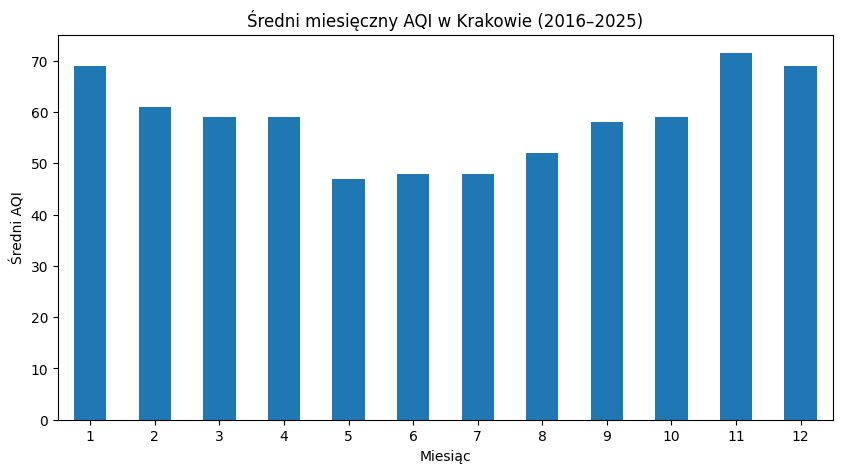

In [26]:
monthly_aqi = df.groupby("month")["aqi"].median()

plt.figure(figsize=(10, 5))

monthly_aqi.plot(kind="bar")

plt.title("Średni miesięczny AQI w Krakowie (2016–2025)")
plt.xlabel("Miesiąc")
plt.ylabel("Średni AQI")
plt.xticks(rotation=0)

plt.show()

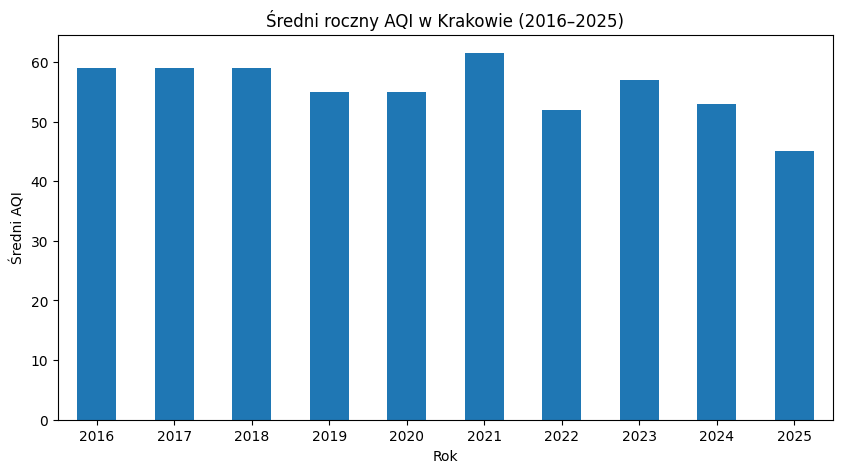

In [ ]:
##Analiza w celu odpowiedzi na zadanie 10
yearly_aqi = df.groupby("year")["aqi"].median()

plt.figure(figsize=(10, 5))

yearly_aqi.plot(kind="bar")

plt.title("Średni roczny AQI w Krakowie (2016–2025)")
plt.xlabel("Rok")
plt.ylabel("Średni AQI")
plt.xticks(rotation=0)

plt.show()

## Zadanie 8 — Wygładzanie trendu (średnia krocząca) - ZADANIE DODATKOWE
**Co zrobisz:** wygładź dzienny przebieg złożonego AQI w horyzoncie około miesiąca i porównaj go z przebiegiem pełnym. Użyj metody `.rolling()`: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html

**Po co:** ułatwia to dostrzeżenie trwałych zmian, eliminując codzienny szum.

**Do przemyślenia:**
- Co oznacza parametr `window` w metodzie `.rolling()`? Jak dobrać jego wartość?
- Co się stanie z pierwszymi N wierszami po zastosowaniu średniej kroczącej?

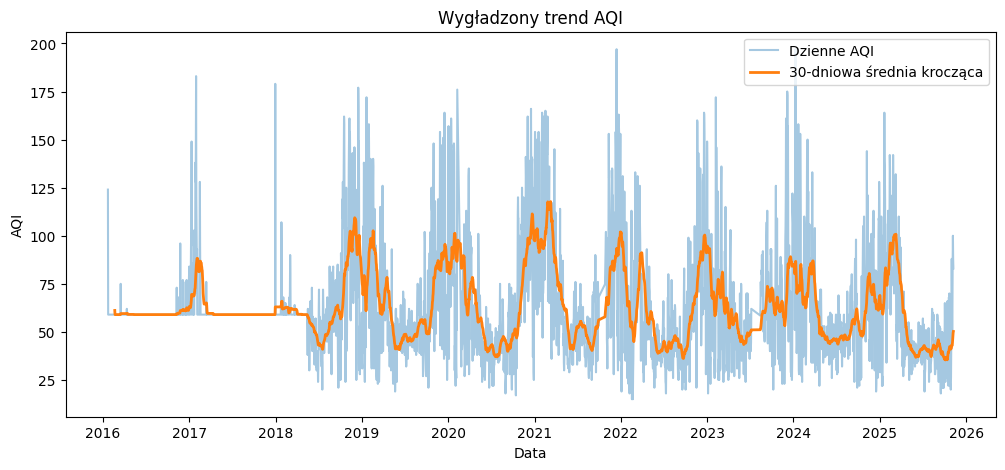

In [29]:
df["aqi_rolling"] = df["aqi"].rolling(window=30).mean()

plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["aqi"], alpha=0.4, label="Dzienne AQI")
plt.plot(df["date"], df["aqi_rolling"], linewidth=2, label="30-dniowa średnia krocząca")

plt.title("Wygładzony trend AQI")
plt.xlabel("Data")
plt.ylabel("AQI")

plt.legend()
plt.show()

## Zadanie 9 — Kategorie jakości powietrza (EPA) - ZADANIE DODATKOWE
**Co zrobisz:** zaklasyfikuj dni do kategorii jakości powietrza według skali EPA i pokaż rozkład tych kategorii.  
**Po co:** kategorie są praktyczne w komunikacji ryzyka dla mieszkańców.

### Czym jest skala EPA?
**EPA (Environmental Protection Agency)** to amerykańska agencja ochrony środowiska, która opracowała ustandaryzowaną skalę **AQI (Air Quality Index)**. Skala ta pozwala porównywać różne zanieczyszczenia w jednej, intuicyjnej skali ryzyka zdrowotnego od 0 do 500.

Każda wartość AQI = 100 odpowiada stężeniu uznanemu za graniczne dla ochrony zdrowia publicznego. Wartości powyżej 100 oznaczają powietrze niezdrowe — najpierw dla grup wrażliwych (dzieci, astmatycy, seniorzy), potem dla wszystkich.

**Skala kategorii EPA:**
| Zakres AQI | Kategoria | Znaczenie |
|------------|-----------|-----------|
| 0–50 | Dobra (Good) | Jakość powietrza zadowalająca, minimalne ryzyko |
| 51–100 | Umiarkowana (Moderate) | Akceptowalna, wrażliwe osoby mogą odczuwać objawy |
| 101–150 | Niezdrowa dla wrażliwych grup | Dzieci, seniorzy i osoby z chorobami płuc powinny ograniczyć wysiłek na zewnątrz |
| 151–200 | Niezdrowa (Unhealthy) | Każdy może odczuwać skutki zdrowotne |
| 201–300 | Bardzo niezdrowa | Poważne zagrożenie zdrowia dla całej populacji |
| 301–500 | Niebezpieczna (Hazardous) | Stan alarmowy — należy unikać przebywania na zewnątrz |

> **Uwaga:** W danych z Krakowa maksymalny AQI wynosi ~197. Kategorie powyżej 200 mogą być puste — to oznacza, że w analizowanym okresie nie wystąpiły ekstremalne zdarzenia (np. pożary, katastrofy przemysłowe).

**Do przemyślenia:**
- Jak przypisać wartość liczbową do kategorii tekstowej? Poszukaj funkcji `pd.cut()`
- Co mówi rozkład kategorii o jakości powietrza w Krakowie?

aqi_category
Dobra                            1173
Umiarkowana                      1955
Niezdrowa dla wrażliwych grup     312
Niezdrowa                          56
Bardzo niezdrowa                    0
Niebezpieczna                       0
Name: count, dtype: int64


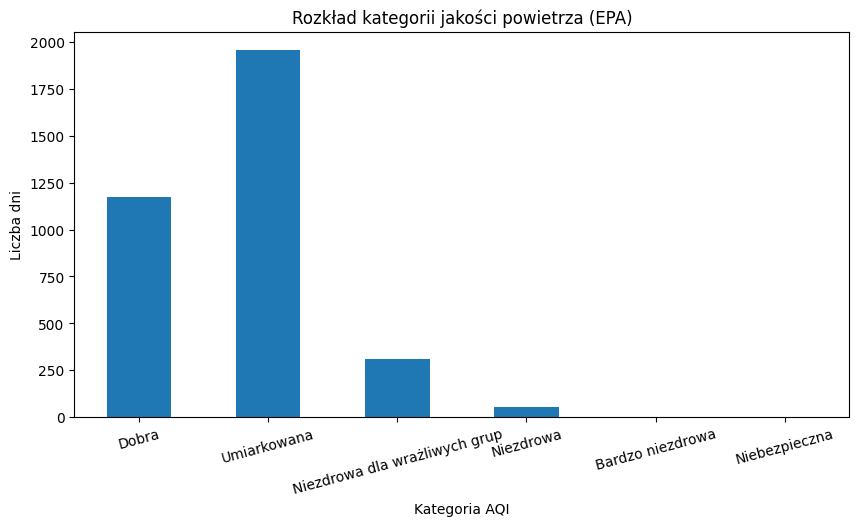

In [31]:
bins = [0, 50, 100, 150, 200, 300, 500]

labels = [
    "Dobra",
    "Umiarkowana",
    "Niezdrowa dla wrażliwych grup",
    "Niezdrowa",
    "Bardzo niezdrowa",
    "Niebezpieczna"
]

df["aqi_category"] = pd.cut(
    df["aqi"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


category_counts = df["aqi_category"].value_counts().sort_index()

print(category_counts)


plt.figure(figsize=(10, 5))

category_counts.plot(kind="bar")

plt.title("Rozkład kategorii jakości powietrza (EPA)")
plt.xlabel("Kategoria AQI")
plt.ylabel("Liczba dni")

plt.xticks(rotation=15)

plt.show()

aqi_category  Dobra  Umiarkowana  Niezdrowa dla wrażliwych grup  Niezdrowa
year                                                                      
2016              0          342                              1          0
2017              0          349                             10          2
2018             84          241                             31          8
2019            153          157                             45          7
2020            162          145                             51          8
2021            109          160                             54         15
2022            179          144                             36          5
2023            133          158                             30          5
2024            167          159                             30          4
2025            186          100                             24          2


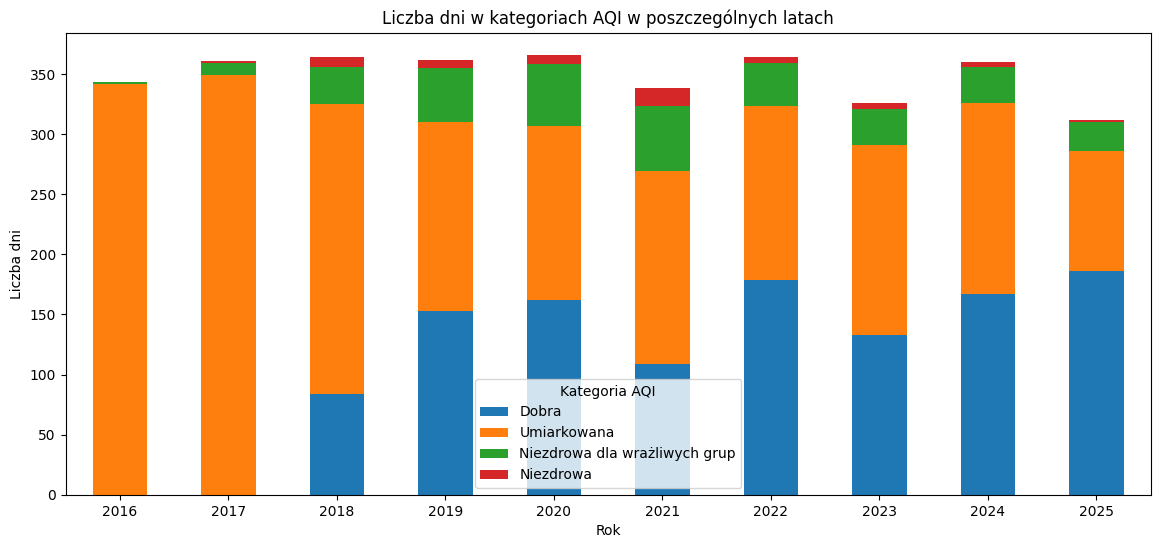

In [33]:
# liczba dni w każdej kategorii AQI dla każdego roku
yearly_categories = (
    df.groupby(["year", "aqi_category"])
      .size()
      .unstack(fill_value=0)
)

print(yearly_categories)

yearly_categories.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Liczba dni w kategoriach AQI w poszczególnych latach")
plt.xlabel("Rok")
plt.ylabel("Liczba dni")

plt.legend(title="Kategoria AQI")
plt.xticks(rotation=0)

plt.show()

## Zadanie 10 — Wnioski końcowe
**Co zrobisz:** sformułuj krótką interpretację wyników, odpowiadając na poniższe pytania:

1. W jakich miesiącach/porach roku jakość powietrza w Krakowie jest najgorsza? Dlaczego?
2. Która substancja najczęściej dominuje w złożonym AQI (decyduje o jego wartości)?
3. Czy widać poprawę jakości powietrza na przestrzeni lat 2016–2025? Na jakiej podstawie to oceniasz?
4. Jakie rekomendacje mógłbyś/mogłabyś sformułować dla mieszkańców Krakowa na podstawie tych danych?

**Po co:** wnioski łączą wyniki obliczeń z praktycznym zrozumieniem zjawiska.

1. Jakość powietrza w Krakowie jest skorelowana z porą roku. W miesiącach zimowych (sezon grzewczy), widać znaczący wzrost zanieczyszczeń.
2. Największy wpływ na AQI ma pył zawieszony PM10.
3. Stan powietrza w Krakowie ulega systematycznej poprawie (w zadaniu nr 9 dodałem podział kategorii jakości powietrza dla każdego roku). Na podstawie tych danych można łatwo dostrzec wzrost liczby dni z dobrą jakością powietrza oraz spadek liczby dni z niezdrowym powietrzem (od roku 2021).
4. Mieszkańcą Krakowa rekmendowałbym ograniczenie uprawiania sportu na "świeżym powietrzu", w czasie złej jakości powietrza. W celu poprawy jakości powuietrza sugerowałbym wybór transportu publicznego zamiast samochodu.
